In [58]:
from utils import *

import pingouin as pg
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from factor_analyzer import FactorAnalyzer
from semopy import ModelMeans, calc_stats
from pingouin import partial_corr
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk import FreqDist
import textstat


nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/matuskrajcovic/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matuskrajcovic/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [40]:
messagesL = pd.read_csv("data/messages-labeled.csv", index_col=0)
answers = pd.read_csv("data/answers.csv", index_col=0)
followupMessages = messagesL[(messagesL.role=='user') & (messagesL.section=='follow_up')].copy()

## Prepare BFI/CFQ data

In [41]:
temp = answers[answers.section=='questionnaire']
bfi = temp[temp.form=='bfi'].sort_values('questionID').copy()
cfq = temp[temp.form=='cfq'].sort_values('questionID').copy()
order_bfi = bfi['question'].unique()
order_cfq = cfq['question'].unique()

bfi_map = {
    'Disagree strongly': 1,
    'Disagree a little': 2,
    'Neutral, no opinion': 3,
    'Agree a little': 4,
    'Agree strongly': 5
}
cfq_map = {
    'Never': 0,
    'Very rarely': 1,
    'Occasionally': 2,
    'Quite often': 3,
    'Very often': 4
}

bfi_pivot = bfi.pivot_table(
    index=['respondent', 'type'], 
    columns='question',
    values='answer',
    aggfunc='first'
)
cfq_pivot = cfq.pivot_table(
    index=['respondent', 'type'], 
    columns='question',
    values='answer',
    aggfunc='first'
)

bfi_pivot = bfi_pivot[order_bfi].copy()
cfq_pivot = cfq_pivot[order_cfq].copy()
bfi_pivot = bfi_pivot.drop('I prefer summer over winter.', axis=1)
cfq_pivot = cfq_pivot.drop('Do you go to summer vacations?', axis=1)

bfi_data = bfi_pivot.map(lambda x: bfi_map[x])
cfq_data = cfq_pivot.map(lambda x: cfq_map[x])

bfi_data.columns = ["B" + str(x) for x in range(1, bfi_data.shape[1]+1)]
bfi_data.loc[:, ['B1', 'B3', 'B7', 'B8', 'B10', 'B14', 'B17', 'B20', 'B21', 'B19', 'B24', 'B28', 'B26', 'B27', 'B30']] = 6 - bfi_data.loc[:, ['B1', 'B3', 'B7', 'B8', 'B10', 'B14', 'B17', 'B20', 'B21', 'B19', 'B24', 'B28', 'B26', 'B27', 'B30']]

cfq_data.columns = ["C" + str(x) for x in range(1, cfq_data.shape[1]+1)]
cfq_data = cfq_data.reset_index()
bfi_data = bfi_data.reset_index()

## Reliability

In [42]:
for i in ['avatar', 'classic']:
    x = bfi_data[bfi_data.type==i].drop(['respondent', 'type'], axis=1)
    print(i, "all BFI:", pg.cronbach_alpha(x))
    print(i, "Extraversion", pg.cronbach_alpha(x.loc[:, ['B1', 'B6', 'B11', 'B16', 'B21', 'B26']]))
    print(i, "Agreeableness", pg.cronbach_alpha(x.loc[:, ['B2', 'B7', 'B12', 'B17', 'B22', 'B27']]))
    print(i, "Conscientiousness", pg.cronbach_alpha(x.loc[:, ['B3', 'B8', 'B13', 'B18', 'B23', 'B28']]))
    print(i, "Negative Emotionality", pg.cronbach_alpha(x.loc[:, ['B4', 'B9', 'B14', 'B19', 'B24', 'B29']]))
    print(i, "Open-Mindedness", pg.cronbach_alpha(x.loc[:, ['B5', 'B10', 'B15', 'B20', 'B25', 'B30']]))

    x = cfq_data[cfq_data.type==i].drop(['respondent', 'type'], axis=1)
    print(i, "all CFQ:", pg.cronbach_alpha(x))
    print(i, "forgetfulness:", pg.cronbach_alpha(x.loc[:, ['C1', 'C2', 'C5', 'C7', 'C17', 'C20', "C22", "C23"]]))
    print(i, "distractibility:", pg.cronbach_alpha(x.loc[:, ['C8', 'C9', 'C10', 'C11', 'C14', 'C19', 'C21', 'C25']]))
    print(i, "false triggering:", pg.cronbach_alpha(x.loc[:, ['C2', 'C3', 'C5', 'C6', 'C12', 'C18', 'C23', 'C24']]))

avatar all BFI: (np.float64(0.642123650002697), array([0.372, 0.833]))
avatar Extraversion (np.float64(0.7029736618521665), array([0.443, 0.866]))
avatar Agreeableness (np.float64(0.7535609079882167), array([0.538, 0.889]))
avatar Conscientiousness (np.float64(0.8615003099814011), array([0.74 , 0.938]))
avatar Negative Emotionality (np.float64(0.9113752122241087), array([0.834, 0.96 ]))
avatar Open-Mindedness (np.float64(0.8214252005663049), array([0.665, 0.92 ]))
avatar all CFQ: (np.float64(0.8751686491546892), array([0.78 , 0.942]))
avatar forgetfulness: (np.float64(0.7396553503250438), array([0.523, 0.881]))
avatar distractibility: (np.float64(0.63606923506421), array([0.333, 0.834]))
avatar false triggering: (np.float64(0.6639652250792012), array([0.384, 0.847]))
classic all BFI: (np.float64(0.7673538713091533), array([0.592, 0.892]))
classic Extraversion (np.float64(0.5648427760077572), array([0.184, 0.804]))
classic Agreeableness (np.float64(0.6605080831408775), array([0.363, 0.8

In [43]:
bfi_items = [f"B{i}" for i in range(1, 31)]
cfq_items = [f"C{i}" for i in range(1, 26)]

classic_bfi = bfi_data[bfi_data["type"] == "classic"][bfi_items].dropna().astype(float)
avatar_bfi  = bfi_data[bfi_data["type"] == "avatar"][bfi_items].dropna().astype(float)

classic_cfq = cfq_data[cfq_data["type"] == "classic"][cfq_items].dropna().astype(float)
avatar_cfq  = cfq_data[cfq_data["type"] == "avatar"][cfq_items].dropna().astype(float)

bfi_data[bfi_data.columns[2:]] = bfi_data.iloc[:, 2:].astype(float)
cfq_data[cfq_data.columns[2:]] = cfq_data.iloc[:, 2:].astype(float)

bfi_data.type = bfi_data.type.map({'avatar':1, 'classic':0})
cfq_data.type = cfq_data.type.map({'avatar':1, 'classic':0})

In [44]:
print(classic_bfi.describe().T[["mean","std"]])
print(avatar_bfi.describe().T[["mean","std"]])

     mean       std
B1   2.15  1.039990
B2   4.55  0.686333
B3   3.40  1.391705
B4   3.55  1.145931
B5   3.45  1.538112
B6   3.15  1.225819
B7   4.10  1.119210
B8   2.75  1.371707
B9   2.90  1.252366
B10  3.25  1.118034
B11  3.50  1.277333
B12  3.85  1.182103
B13  4.50  0.688247
B14  1.90  0.788069
B15  3.55  1.190975
B16  2.95  1.503505
B17  3.85  1.308877
B18  3.80  1.281447
B19  1.95  0.998683
B20  3.40  1.231174
B21  2.90  1.333772
B22  4.80  0.410391
B23  4.15  1.089423
B24  2.15  1.136708
B25  4.25  0.850696
B26  3.30  1.341641
B27  3.75  1.069924
B28  3.30  1.128576
B29  2.45  1.145931
B30  3.30  1.301821
     mean       std
B1   2.10  1.071153
B2   4.55  0.510418
B3   3.60  1.569445
B4   3.95  1.190975
B5   4.10  1.119210
B6   2.55  1.316894
B7   4.25  1.019546
B8   2.70  1.490320
B9   3.00  1.297771
B10  3.60  0.994723
B11  3.35  1.225819
B12  3.70  1.174286
B13  4.05  0.759155
B14  2.75  1.292692
B15  3.80  1.005249
B16  3.15  1.424411
B17  4.05  1.190975
B18  3.85  1.460894


In [45]:
print(avatar_cfq.describe().T[["mean","std"]])
print(classic_cfq.describe().T[["mean","std"]])

     mean       std
C1   2.55  1.099043
C2   2.10  1.293709
C3   1.30  1.128576
C4   1.40  1.465390
C5   1.45  0.887041
C6   1.70  0.864505
C7   1.65  1.348488
C8   1.80  0.951453
C9   1.75  0.910465
C10  1.25  1.164158
C11  1.35  1.424411
C12  0.90  1.119210
C13  1.75  1.251315
C14  1.65  1.182103
C15  2.45  0.887041
C16  0.95  1.190975
C17  2.00  1.025978
C18  0.90  0.911910
C19  1.90  1.119210
C20  1.65  0.875094
C21  2.25  1.164158
C22  2.05  0.887041
C23  1.20  0.951453
C24  1.35  1.039990
C25  1.80  1.151658
     mean       std
C1   2.55  1.099043
C2   1.70  1.031095
C3   0.90  0.640723
C4   1.10  1.119210
C5   1.00  0.794719
C6   1.65  1.136708
C7   1.95  1.538112
C8   1.60  1.187656
C9   1.60  0.753937
C10  1.35  0.875094
C11  1.20  1.321881
C12  0.55  0.604805
C13  1.50  0.888523
C14  1.15  0.875094
C15  2.25  1.019546
C16  0.85  0.988087
C17  1.55  0.887041
C18  0.35  0.489360
C19  1.90  1.165287
C20  1.55  1.050063
C21  2.35  1.386969
C22  2.10  0.911910
C23  0.90  0.852242


## KMO/Barlett's

In [46]:
for data in [avatar_bfi, classic_bfi]:
    kmo_item, kmo_overall = calculate_kmo(data[bfi_items])
    bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(data[bfi_items])
    print(f"KMO = {kmo_overall:.2f}, Bartlett chi = {bartlett_chi2:.2f}, p = {bartlett_p:.3g}")

for data in [avatar_cfq, classic_cfq]:
    kmo_item, kmo_overall = calculate_kmo(data[cfq_items])
    bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(data[cfq_items])
    print(f"KMO = {kmo_overall:.2f}, Bartlett chi = {bartlett_chi2:.2f}, p = {bartlett_p:.3g}")

kmo_item, kmo_overall = calculate_kmo(bfi_data[bfi_items])
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(bfi_data[bfi_items])
print(f"KMO = {kmo_overall:.2f}, MSA={kmo_item}, Bartlett chi = {bartlett_chi2:.2f}, p = {bartlett_p:.3g}")
print((kmo_item < 0.5).sum())

kmo_item, kmo_overall = calculate_kmo(cfq_data[cfq_items])
bartlett_chi2, bartlett_p = calculate_bartlett_sphericity(cfq_data[cfq_items])
print(f"KMO = {kmo_overall:.2f}, MSA={kmo_item}, Bartlett chi = {bartlett_chi2:.2f}, p = {bartlett_p:.3g}")
print((kmo_item < 0.5).sum())

KMO = nan, Bartlett chi = nan, p = nan
KMO = nan, Bartlett chi = nan, p = nan
KMO = nan, Bartlett chi = 2306.19, p = 8.22e-306
KMO = nan, Bartlett chi = nan, p = nan
KMO = 0.39, MSA=[0.26360055 0.48190081 0.45052986 0.29417226 0.48519029 0.49456869
 0.62826161 0.66715964 0.4082251  0.6069463  0.34914174 0.37782849
 0.49379886 0.56756888 0.20593221 0.55004359 0.60725877 0.28656349
 0.40696824 0.28602395 0.21612386 0.50147398 0.32752338 0.71895219
 0.30567542 0.40853103 0.31286001 0.35134228 0.27914049 0.22600959], Bartlett chi = 806.00, p = 1.55e-24
22
KMO = 0.59, MSA=[0.68693525 0.78582371 0.3857481  0.33714335 0.44031968 0.35483705
 0.53567495 0.64817993 0.39786598 0.49889885 0.59317052 0.46115477
 0.66802697 0.78833348 0.71925479 0.74878603 0.83852643 0.63016541
 0.55449805 0.6547869  0.63489961 0.49244178 0.6054843  0.45421737
 0.57356089], Bartlett chi = 596.26, p = 8.46e-22
9


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:109: RuntimeWarning: invalid value encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:109: RuntimeWarning: invalid value encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/factor_analyzer/factor_analyzer.py:109: RuntimeWarning: invalid value encountered in log
  statistic = -np.log(corr_det) * (n - 1 - (2 * p + 5) / 6)
/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/Users/matuskrajcovic/Desktop/a

## Correlations

Text(0.5, 1.0, 'Classic CFQ Correlation')

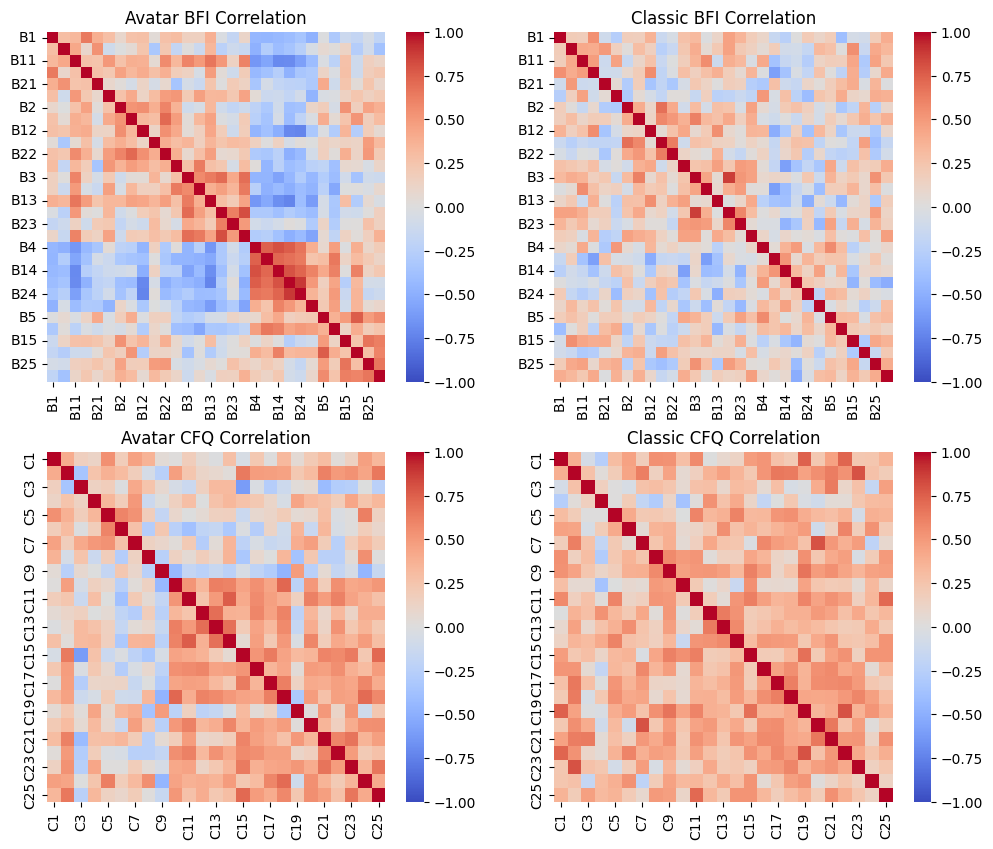

In [47]:
bfi_order = ['B1', 'B6', 'B11', 'B16', 'B21', 'B26', 'B2', 'B7', 'B12', 'B17', 'B22', 'B27','B3', 'B8', 'B13', 'B18', 'B23', 'B28',
         'B4', 'B9', 'B14', 'B19', 'B24', 'B29','B5', 'B10', 'B15', 'B20', 'B25', 'B30']

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
avatar_bfi_corr = avatar_bfi.loc[:, bfi_order].corr()
classic_bfi_corr = classic_bfi.loc[:, bfi_order].corr()
avatar_cfq_corr = avatar_cfq.corr()
classic_cfq_corr = classic_cfq.corr()
sns.heatmap(avatar_bfi_corr, vmin=-1, vmax=1, cmap='coolwarm', ax=axs[0, 0]); axs[0, 0].set_title('Avatar BFI Correlation')
sns.heatmap(classic_bfi_corr, vmin=-1, vmax=1, cmap='coolwarm', ax=axs[0, 1]); axs[0, 1].set_title('Classic BFI Correlation')
sns.heatmap(avatar_cfq_corr, vmin=-1, vmax=1, cmap='coolwarm', ax=axs[1, 0]); axs[1, 0].set_title('Avatar CFQ Correlation')
sns.heatmap(classic_cfq_corr, vmin=-1, vmax=1, cmap='coolwarm', ax=axs[1, 1]); axs[1, 1].set_title('Classic CFQ Correlation')

## Factor analysis

In [48]:
domains = {
    "Extraversion": ["B1", "B6", "B11", "B16", "B21", "B26"],
    "Agreeableness": ["B2", "B7", "B12", "B17", "B22", "B27"],
    "Conscientiousness": ["B3", "B8", "B13", "B18", "B23", "B28"],
    "Neuroticism": ["B4", "B9", "B14", "B19", "B24", "B29"],
    "Openness": ["B5", "B10", "B15", "B20", "B25", "B30"],
}

avatar_bfi
Factors:  8


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


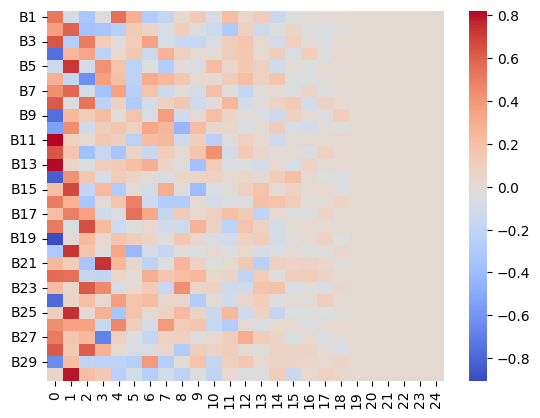

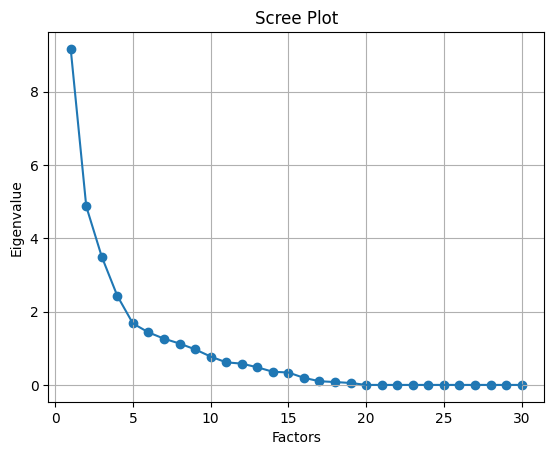

/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor,SS Loadings,Proportion Var,Cumulative Var
0,1,5.902332,0.196744,0.196744
1,2,3.866376,0.128879,0.325624
2,3,3.313163,0.110439,0.436062
3,4,2.748783,0.091626,0.527688
4,5,2.230120,0.074337,0.602026
5,6,2.028350,0.067612,0.669637
6,7,2.021896,0.067397,0.737034
7,8,1.718221,0.057274,0.794308


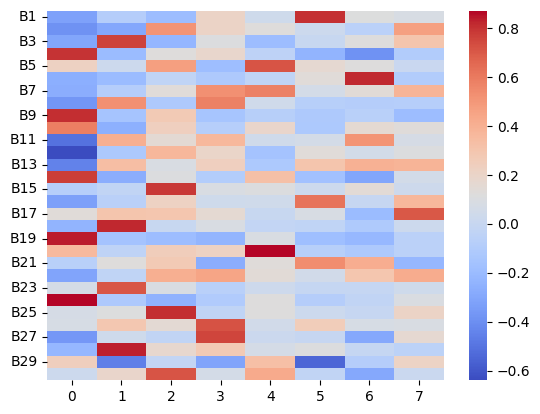

,0,1,2,3,4,5,6,7,communality
B1,-0.323049,-0.088230,-0.193253,0.209370,0.035957,0.799768,0.109922,0.083393,0.853286
B2,-0.386931,-0.302413,0.513296,0.206415,0.124737,0.025549,-0.058201,0.465826,0.783843
B3,-0.306173,0.760564,-0.227973,0.105158,-0.190998,0.000688,0.119980,0.304073,0.878567
B4,0.795216,-0.197982,0.122245,0.184733,-0.046585,-0.240886,-0.389149,-0.099536,0.942176
B5,0.223411,0.022916,0.471184,-0.185843,0.716606,0.164271,0.121418,0.006047,0.862278
B6,-0.264482,-0.199356,-0.033248,-0.117452,-0.033220,0.133739,0.822562,-0.101063,0.830405
B7,-0.271651,-0.085551,0.133996,0.523083,0.578732,0.061307,0.143503,0.385224,0.880364
B8,-0.370967,0.525742,-0.119035,0.579459,0.039159,-0.078306,-0.085956,-0.083861,0.786050
B9,0.809032,-0.152416,0.273750,-0.143751,-0.076336,-0.116977,-0.070981,-0.194916,0.835909
B10,0.583193,-0.260170,0.238680,-0.083907,0.189315,-0.122824,0.161268,0.130529,0.565782


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


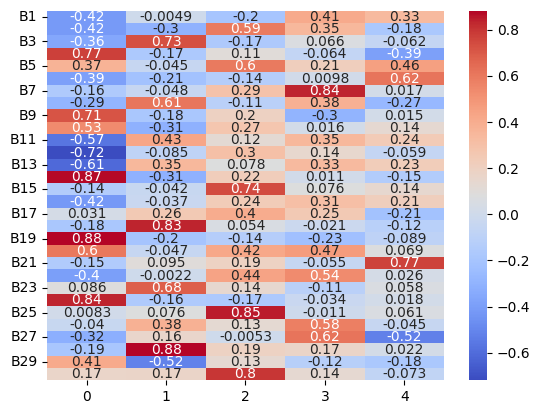

,0,1,2,3,4,communality
B1,-0.418170,-0.004914,-0.197843,0.408359,0.334792,0.492875
B2,-0.417689,-0.303970,0.590823,0.350009,-0.176568,0.769616
B3,-0.362744,0.729522,-0.168448,0.065987,-0.061830,0.700338
B4,0.770417,-0.170520,0.105995,-0.063667,-0.389845,0.789888
B5,0.370846,-0.044680,0.595010,0.213549,0.455269,0.746433
B6,-0.393362,-0.212765,-0.136773,0.009778,0.617847,0.600541
B7,-0.160058,-0.048409,0.290239,0.837482,0.016903,0.813862
B8,-0.288764,0.612490,-0.110978,0.383316,-0.274066,0.692888
B9,0.714122,-0.182990,0.198350,-0.297395,0.014834,0.671461
B10,0.532875,-0.308614,0.274352,0.016349,0.135668,0.473140


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


classic_bfi
Factors:  10


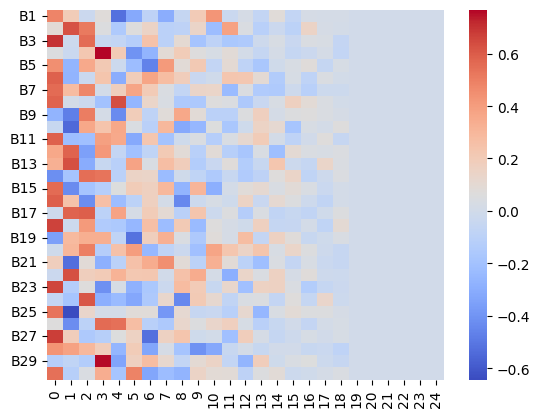

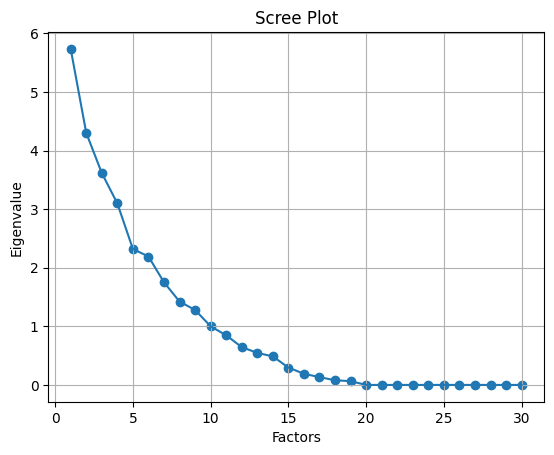

/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor,SS Loadings,Proportion Var,Cumulative Var
0,1,3.116770,0.103892,0.103892
1,2,3.056262,0.101875,0.205768
2,3,2.765714,0.092190,0.297958
3,4,2.700263,0.090009,0.387967
4,5,2.450730,0.081691,0.469658
5,6,2.331346,0.077712,0.547370
6,7,2.293724,0.076457,0.623827
7,8,2.272153,0.075738,0.699565
8,9,2.168830,0.072294,0.771860
9,10,2.072454,0.069082,0.840942


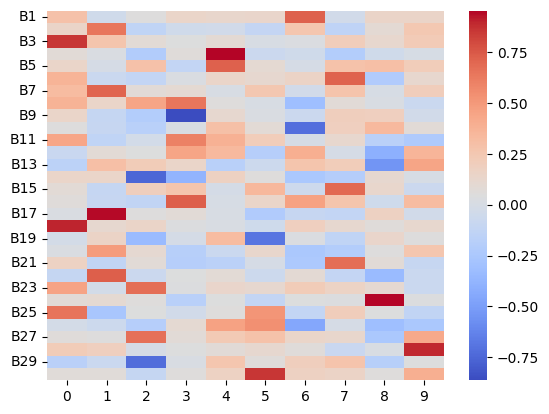

,0,1,2,3,4,5,6,7,8,9,communality
B1,0.287745,-0.044447,0.050892,0.144117,0.123705,0.137111,0.722397,-0.035162,0.146420,0.146735,0.708298
B2,0.144954,0.646348,-0.138080,-0.040240,-0.039581,-0.116092,0.260813,-0.144900,0.093358,0.249341,0.634413
B3,0.859845,0.268617,0.086405,0.038710,0.091291,0.006963,0.028017,0.208417,0.119052,0.226681,0.938616
B4,0.076248,0.022208,-0.216310,0.062780,0.952472,-0.073917,-0.045450,-0.209955,-0.045515,0.001950,1.017926
B5,0.143318,-0.008167,0.293525,-0.122687,0.724894,0.095281,-0.008975,0.286534,0.304812,0.209371,0.875295
B6,0.371156,-0.080300,-0.124699,0.021400,0.140329,0.114979,0.153944,0.719234,-0.219945,0.120051,0.796909
B7,0.326983,0.711446,0.077440,0.098946,0.004724,0.256922,-0.034187,0.278097,-0.000375,0.207931,0.816635
B8,0.378724,0.140163,0.444879,0.647546,0.058685,0.004471,-0.311859,0.078284,0.013113,-0.076374,0.893163
B9,0.140013,-0.108949,-0.206350,-0.863928,0.112843,0.020740,-0.068431,0.196402,0.190435,-0.033626,0.914242
B10,0.049449,-0.100141,-0.177548,0.016327,0.299229,0.087061,-0.719816,0.187970,0.338418,0.080559,0.815865


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


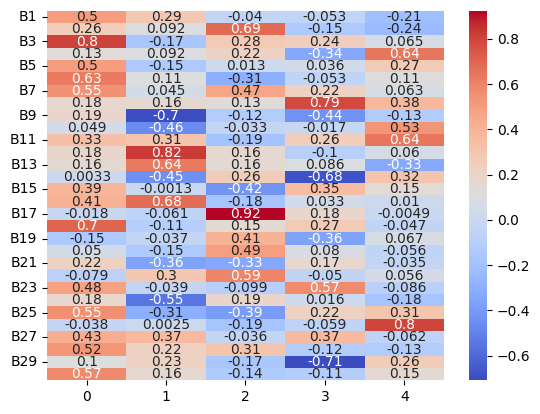

,0,1,2,3,4,communality
B1,0.498716,0.289770,-0.039504,-0.053492,-0.211862,0.381992
B2,0.259385,0.091673,0.693243,-0.152498,-0.240439,0.637337
B3,0.802418,-0.172372,0.275905,0.242996,0.065368,0.813030
B4,0.128636,0.092274,0.219447,-0.337192,0.644024,0.601685
B5,0.498160,-0.151971,0.012638,0.036338,0.267398,0.344240
B6,0.627112,0.106740,-0.306179,-0.053463,0.110985,0.513585
B7,0.545978,0.045084,0.465925,0.222475,0.063181,0.570698
B8,0.175865,0.159122,0.131818,0.788493,0.380350,0.840012
B9,0.188164,-0.701996,-0.118790,-0.437283,-0.125268,0.749224
B10,0.048611,-0.461700,-0.033499,-0.016567,0.529971,0.497796


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


avatar_cfq
Factors:  7


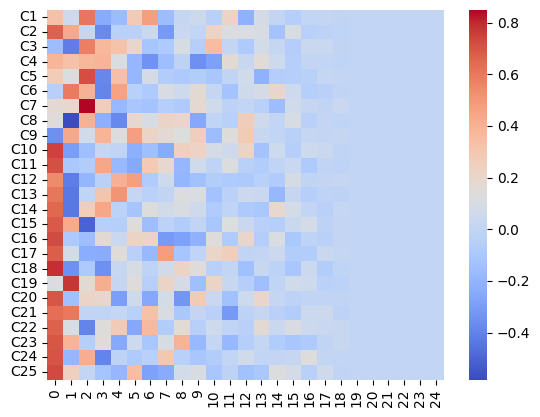

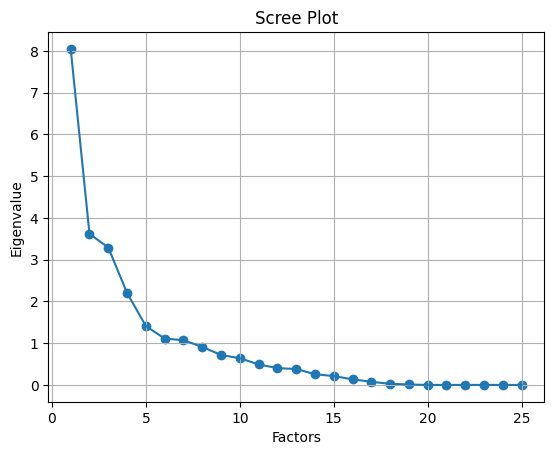

/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor,SS Loadings,Proportion Var,Cumulative Var
0,1,4.952336,0.198093,0.198093
1,2,2.800646,0.112026,0.310119
2,3,2.675137,0.107005,0.417125
3,4,2.565632,0.102625,0.519750
4,5,2.381778,0.095271,0.615021
5,6,2.099323,0.083973,0.698994
6,7,1.794653,0.071786,0.770780


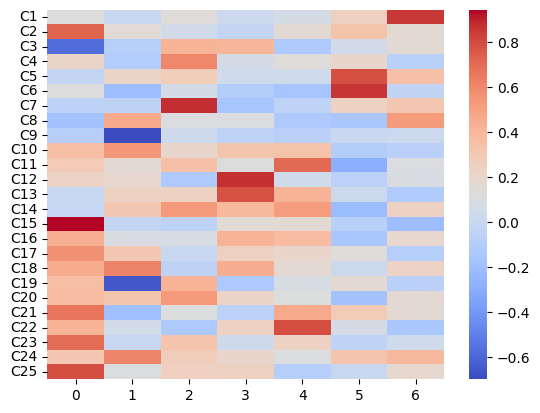

,0,1,2,3,4,5,6,communality
C1,0.127814,-0.003172,0.138754,0.017910,0.075080,0.249399,0.852944,0.831270
C2,0.724910,0.155347,0.050856,-0.023361,0.165752,0.338189,0.166461,0.722315
C3,-0.572900,-0.088345,0.415868,0.406974,-0.128636,0.048440,0.162290,0.719825
C4,0.218545,-0.112767,0.599726,0.071518,0.141923,0.195734,-0.075629,0.489438
C5,-0.020251,0.214085,0.272317,0.042088,0.043635,0.783579,0.347781,0.859022
C6,0.128925,-0.210134,0.060034,-0.106580,-0.166379,0.854310,-0.031642,0.834269
C7,-0.061921,-0.055345,0.873791,-0.161993,-0.046617,0.243332,0.314971,0.957240
C8,-0.179075,0.458070,0.106662,0.105015,-0.130322,-0.152655,0.524803,0.580007
C9,-0.085901,-0.697199,0.035643,-0.049459,-0.072439,0.005448,0.016069,0.502718
C10,0.362898,0.540848,0.194674,0.321896,0.334631,-0.106651,-0.074284,0.694597


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


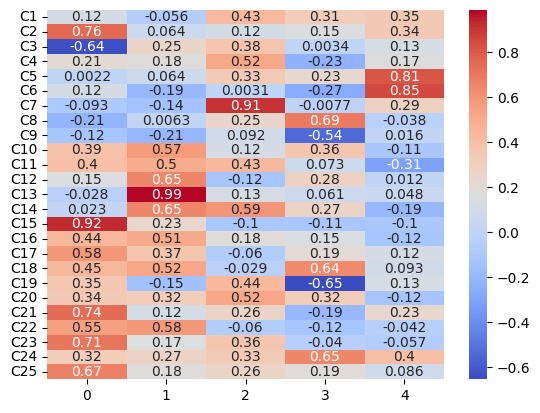

,0,1,2,3,4,communality
C1,0.119625,-0.055825,0.427139,0.314906,0.345049,0.418099
C2,0.755692,0.063627,0.117050,0.149877,0.342708,0.728731
C3,-0.640506,0.250431,0.376512,0.003385,0.125128,0.630393
C4,0.207033,0.178902,0.517539,-0.225987,0.171694,0.423264
C5,0.002243,0.063673,0.329490,0.226979,0.809164,0.818888
C6,0.120078,-0.189906,0.003129,-0.265273,0.849989,0.843343
C7,-0.092773,-0.136712,0.908997,-0.007713,0.287433,0.936249
C8,-0.213655,0.006297,0.248016,0.686370,-0.037752,0.579729
C9,-0.118868,-0.205365,0.091814,-0.544130,0.016015,0.361068
C10,0.386414,0.566815,0.116166,0.358658,-0.114063,0.625736


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


classic_cfq
Factors:  7


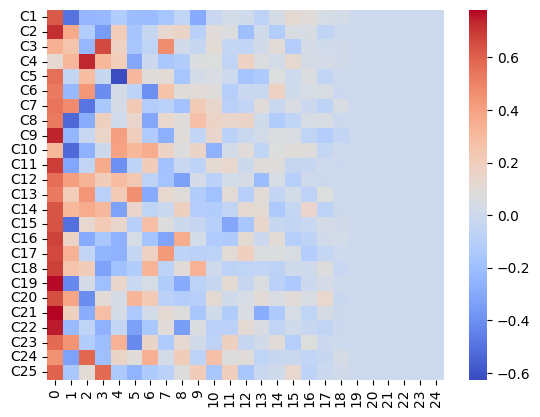

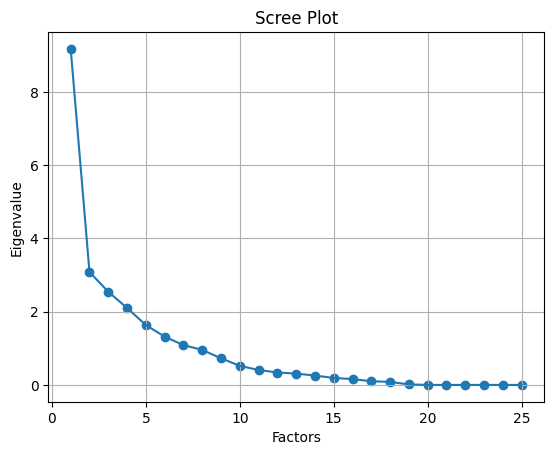

/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Factor,SS Loadings,Proportion Var,Cumulative Var
0,1,4.620432,0.184817,0.184817
1,2,3.141236,0.125649,0.310467
2,3,2.678921,0.107157,0.417624
3,4,2.592955,0.103718,0.521342
4,5,2.518671,0.100747,0.622089
5,6,2.041512,0.081660,0.703749
6,7,1.864387,0.074575,0.778325


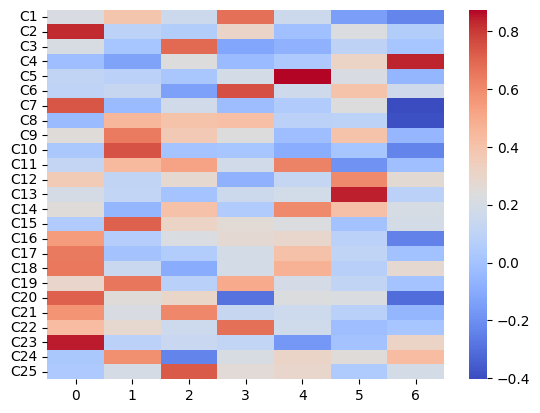

,0,1,2,3,4,5,6,communality
C1,0.213800,0.394274,0.155416,0.672462,0.157485,-0.144062,-0.230624,0.776264
C2,0.827110,0.091328,0.058644,0.308318,-0.010770,0.222848,0.058896,0.844197
C3,0.205335,0.011842,0.689143,-0.121150,-0.071963,0.095780,0.012246,0.546401
C4,-0.023163,-0.132506,0.240034,-0.038716,0.032184,0.313947,0.833606,0.871708
C5,0.112510,0.086770,0.021030,0.186971,0.873365,0.211143,-0.055649,0.866033
C6,0.103975,0.134409,-0.139699,0.749645,0.165829,0.404539,0.169881,0.830370
C7,0.736758,-0.034349,0.179423,-0.028444,0.046006,0.238751,-0.402994,0.798517
C8,-0.034293,0.453718,0.402015,0.419303,0.088932,0.092306,-0.392672,0.715087
C9,0.245210,0.639509,0.370020,0.238050,-0.020687,0.403793,-0.050358,0.828696
C10,0.028948,0.746675,0.002096,0.013621,-0.089479,0.014627,-0.233558,0.621321


/Users/matuskrajcovic/Desktop/avatars/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


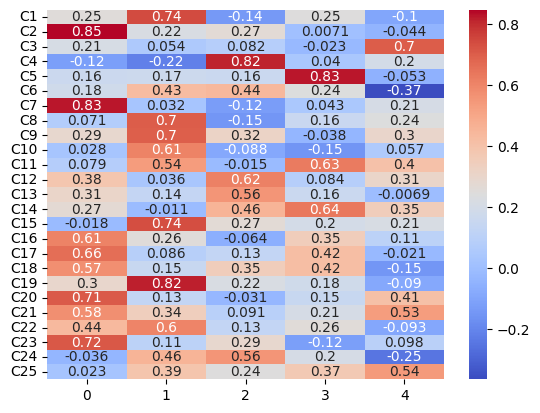

,0,1,2,3,4,communality
C1,0.252858,0.740301,-0.139490,0.245162,-0.099960,0.701536
C2,0.848598,0.222184,0.269631,0.007147,-0.043606,0.844137
C3,0.208824,0.053519,0.081781,-0.023405,0.703918,0.549208
C4,-0.120634,-0.215273,0.815225,0.039871,0.197689,0.766158
C5,0.161224,0.169003,0.158213,0.828726,-0.052975,0.769179
C6,0.183911,0.429662,0.442453,0.238164,-0.365676,0.604639
C7,0.827398,0.031554,-0.124214,0.043217,0.205998,0.745316
C8,0.071327,0.703952,-0.150372,0.156030,0.239096,0.604761
C9,0.292473,0.697488,0.317246,-0.038101,0.302468,0.765613
C10,0.028184,0.611291,-0.088425,-0.153986,0.057110,0.409263


In [49]:
for name, data in {"avatar_bfi": avatar_bfi, "classic_bfi": classic_bfi, "avatar_cfq": avatar_cfq, "classic_cfq": classic_cfq}.items():
    print(name)
    p = 30
    corr = data.corr()

    fa = FactorAnalyzer(n_factors=25, rotation=None)
    fa.fit(data)
    ev, v = fa.get_eigenvalues()
    print('Factors: ', np.sum(ev > 1))
    res = pd.DataFrame(fa.loadings_, index=data.columns)
    sns.heatmap(res, cmap='coolwarm')
    plt.show()

    plt.scatter(range(1,data.shape[1]+1),ev)
    plt.plot(range(1,data.shape[1]+1),ev)
    plt.title('Scree Plot')
    plt.xlabel('Factors')
    plt.ylabel('Eigenvalue')
    plt.grid()
    plt.show()

    fa = FactorAnalyzer(n_factors=np.sum(ev > 1), rotation="varimax")
    fa.fit(data)
    variance_info = fa.get_factor_variance()
    display(pd.DataFrame({
        'Factor': range(1, len(variance_info[0]) + 1),
        'SS Loadings': variance_info[0],
        'Proportion Var': variance_info[1],
        'Cumulative Var': variance_info[2]
    }))
    res = pd.DataFrame(fa.loadings_, index=data.columns)
    sns.heatmap(res, cmap='coolwarm')
    plt.show()
    res['communality'] = fa.get_communalities()
    display(res)
    

    fa = FactorAnalyzer(n_factors=5, rotation="varimax")
    fa.fit(data)
    res = pd.DataFrame(fa.loadings_, index=data.columns)
    sns.heatmap(res, annot=True, cmap='coolwarm')
    plt.show()
    res['communality'] = fa.get_communalities()
    display(res)

In [50]:
model_syntax = """
Extraversion =~ B1 + B6 + B11 + B16 + B21 + B26
Agreeableness =~ B2 + B7 + B12 + B17 + B22 + B27
Conscientiousness =~ B3 + B8 + B13 + B18 + B23 + B28
Neuroticism =~ B4 + B9 + B14 + B19 + B24 + B29
Openness =~ B5 + B10 + B15 + B20 + B25 + B30
Extraversion ~ type
Agreeableness ~ type
Conscientiousness ~ type
Neuroticism ~ type
Openness ~ type
Extraversion ~~ 1*Extraversion
Agreeableness ~~ 1*Agreeableness
Conscientiousness ~~ 1*Conscientiousness
Neuroticism ~~ 1*Neuroticism
Openness ~~ 1*Openness
"""

m = ModelMeans(model_syntax)
res = m.fit(bfi_data)
display(calc_stats(m))
data = m.inspect()
data.head()

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,375,405,28.452139,1.0,35.555316,0.061976,0.199778,0.13576,0.199778,-0.013066,0,136.706926,288.706076,21.646537


,lval,op,rval,Estimate,Std. Err,z-value,p-value
0,Extraversion,~,type,-0.042667,0.349882,-0.121946,0.902942
1,Agreeableness,~,type,-0.047137,0.327769,-0.143811,0.88565
2,Conscientiousness,~,type,0.119740,0.339697,0.35249,0.724471
3,Neuroticism,~,type,0.644569,0.336548,1.915239,0.055462
4,Openness,~,type,0.424135,0.356191,1.190752,0.233751


In [51]:
model_syntax = """
Extraversion =~ B1 + B6 + B11 + B16 + B21 + B26
Agreeableness =~ B2 + B7 + B12 + B17 + B22 + B27
Conscientiousness =~ B3 + B8 + B13 + B18 + B23 + B28
Neuroticism =~ B4 + B9 + B14 + B19 + B24 + B29
Openness =~ B5 + B10 + B15 + B20 + B25 + B30
Extraversion ~~ 1*Extraversion
Agreeableness ~~ 1*Agreeableness
Conscientiousness ~~ 1*Conscientiousness
Neuroticism ~~ 1*Neuroticism
Openness ~~ 1*Openness
"""

m = ModelMeans(model_syntax)
res = m.fit(avatar_bfi)
display(calc_stats(m))

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,370,405,20.76699,1.0,34.409208,0.057632,0.39647,0.339379,0.39647,-0.031511,0,102.593363,197.187929,43.703318


In [52]:
model_syntax = """
Extraversion =~ B1 + B6 + B11 + B16 + B21 + B26
Agreeableness =~ B2 + B7 + B12 + B17 + B22 + B27
Conscientiousness =~ B3 + B8 + B13 + B18 + B23 + B28
Neuroticism =~ B4 + B9 + B14 + B19 + B24 + B29
Openness =~ B5 + B10 + B15 + B20 + B25 + B30
Extraversion ~~ 1*Extraversion
Agreeableness ~~ 1*Agreeableness
Conscientiousness ~~ 1*Conscientiousness
Neuroticism ~~ 1*Neuroticism
Openness ~~ 1*Openness
"""

m = ModelMeans(model_syntax)
res = m.fit(classic_bfi)
display(calc_stats(m))

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,370,405,26.085535,1.0,34.396318,0.072016,0.241618,0.16988,0.241618,-0.015767,0,90.896412,185.490977,49.551794


In [53]:
results = pd.DataFrame()
for item in ["B1", "B6", "B11", "B16", "B21", "B26"]:
    model_text = f"""
    Extraversion =~ B1 + B6 + B11 + B16 + B21 + B26
    Extraversion ~ type
    {item} ~ type
    """
    m = ModelMeans(model_text)
    m.fit(bfi_data)
    est = m.inspect()
    est_item = est[(est["lval"] == item) & (est["rval"]=="type")]
    results = pd.concat([results, est_item])
for item in ["B2", "B7", "B12", "B17", "B22", "B27"]:
    model_text = f"""
    Agreeableness =~ B2 + B7 + B12 + B17 + B22 + B27
    Agreeableness ~ type
    {item} ~ type
    """
    m = ModelMeans(model_text)
    m.fit(bfi_data)
    est = m.inspect()
    est_item = est[(est["lval"] == item) & (est["rval"]=="type")]
    results = pd.concat([results, est_item])
for item in ["B3", "B8", "B13", "B18", "B23", "B28"]:
    model_text = f"""
    CONSC =~ B3 + B8 + B13 + B18 + B23 + B28
    CONSC ~ type
    {item} ~ type
    """
    m = ModelMeans(model_text)
    m.fit(bfi_data)
    est = m.inspect()
    est_item = est[(est["lval"] == item) & (est["rval"]=="type")]
    results = pd.concat([results, est_item])
for item in ["B4", "B9", "B14", "B19", "B24", "B29"]:
    model_text = f"""
    NE =~ B4 + B9 + B14 + B19 + B24 + B29
    NE ~ type
    {item} ~ type
    """
    m = ModelMeans(model_text)
    m.fit(bfi_data)
    est = m.inspect()
    est_item = est[(est["lval"] == item) & (est["rval"]=="type")]
    results = pd.concat([results, est_item])
for item in ["B5", "B10", "B15", "B20", "B25", "B30"]:
    model_text = f"""
    OM =~ B4 + B10 + B15 + B20 + B25 + B30
    OM ~ type
    {item} ~ type
    """
    m = ModelMeans(model_text)
    m.fit(bfi_data)
    est = m.inspect()
    est_item = est[(est["lval"] == item) & (est["rval"]=="type")]
    results = pd.concat([results, est_item])
results

,lval,op,rval,Estimate,Std. Err,z-value,p-value
1,B1,~,type,-0.014820,0.285201,-0.051963,0.958558
1,B6,~,type,-0.619033,0.368031,-1.682015,0.092566
1,B11,~,type,-0.136128,0.353185,-0.385431,0.699918
1,B16,~,type,0.499125,0.41212,1.211115,0.225851
1,B21,~,type,-0.188875,0.388062,-0.486713,0.626461
1,B26,~,type,0.272305,0.439872,0.619055,0.53588
1,B2,~,type,0.054656,0.155363,0.351796,0.724992
1,B7,~,type,0.338043,0.258774,1.306323,0.191443
1,B12,~,type,-0.100698,0.338395,-0.297574,0.766028
1,B17,~,type,0.342778,0.326029,1.051372,0.293088


## Informativeness robustness

In [54]:
results = followupMessages[(followupMessages.section=='follow_up')]
map_type = {'avatar': 1, 'classic': 0}
results['type_bin'] = results['type'].map(map_type).astype('Int64')
x = results.groupby(['respondentID', 'type'])[['informativeness', 'wordCount']].median().reset_index()

In [55]:
partial_corr(data=results, x='informativeness', y='wordCount', covar='type_bin', method='spearman')

,n,r,CI95%,p-val
spearman,2265,0.995566,"[1.0, 1.0]",0.0


In [35]:
from sklearn.linear_model import LinearRegression

X = x['wordCount'].values.reshape(-1, 1)
y = x['informativeness'].values
model = LinearRegression()
model.fit(X, y)
x['resid'] = y - model.predict(X)
mannwhitneyu(x[x.type=='avatar'].resid, x[x.type=='classic'].resid)

MannwhitneyuResult(statistic=np.float64(737.0), pvalue=np.float64(0.5475692501623806))

In [36]:
model.coef_[0], model.intercept_, model.score(X, y)

(np.float64(9.511128579566511),
 np.float64(6.3584450643304535),
 0.9976978489705145)

## Lexical richness

In [60]:
def yules_k(text):
    if not isinstance(text, str):
        return 0
    words = word_tokenize(text)
    N = len(words)
    freq = Counter(FreqDist(words).values())
    summation = 0
    for i in freq:
        summation += freq[i] * (i / len(words)) ** 2

    K = 10**4 * (-1 / N + summation)
    return K

def flesch_reading_ease(text):
    if not isinstance(text, str):
        return 0
    return textstat.flesch_reading_ease(text)

In [61]:
followupMessages['yulesK'] = followupMessages['correctedContent'].apply(lambda x: yules_k(x)) * 100
followupMessages['fleschReadingEase'] = followupMessages['correctedContent'].apply(lambda x: flesch_reading_ease(x))
followupMessages['type_bin'] = followupMessages['type'].map(map_type).astype('Int64')

,mean,std
type,,
avatar,12937.392190,18518.213193
classic,8287.361008,11360.009634


yulesK                                                         
                 0.00          0.25          0.50          0.75           1.00
type                                                                          
avatar  -6.938894e-12  2.775558e-11  12345.679012  18518.518519  500000.000000
classic -6.938894e-12  0.000000e+00   5486.968450  13717.421125  166666.666667

['avatar' 'classic']
0.0006  0.0001  

avatar: M=10539.72, SD=5711.91, MED=12078.91, IQR=(7305.55-14797.67)
classic: M=5985.59, SD=5171.3, MED=7553.99, IQR=(0.0-9973.97)

median
U(80)=1191.5, z=3.77, p=0.0002, r=0.42 [0.23, 0.6], ps=0.74 [0.63, 0.85]

median avatar < classic
U(80)=1191.5, p=0.9999223482393305

median avatar > classic
U(80)=1191.5, p=8.071836149130931e-05

variance
F(1, 80)=0.06, p=0.8036

mean
U(80)=1244.0, p=1.9760426169035876e-05

no aggregation
U(2265)=805357.5, p=1.1412073420280853e-26

                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    yulesK        
No. Observations:     2265       Method:                REML          
No. Groups:           80         Scale:                 224231035.6581
Min. group size:      25         Log-Likelihood:        -25009.7553   
Max. group size:      30         Converged:             Yes           
Mean group size:      28.3                                            
-------

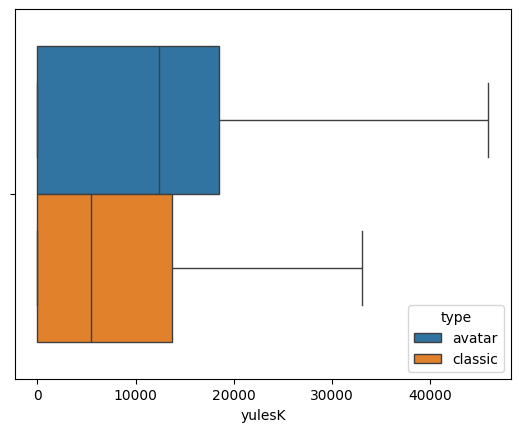

In [63]:
EDA(followupMessages, 'type', 'yulesK')
ANALYSISPAIR(followupMessages, 'type', 'yulesK')
EDAPLOT(followupMessages, 'type', 'yulesK')

,mean,std
type,,
avatar,57.326446,34.395965
classic,71.027506,27.295943


fleschReadingEase                                         
                     0.00       0.25       0.50       0.75    1.00
type                                                              
avatar        -101.076319  41.565551  62.931324  80.097647  121.22
classic       -301.780000  56.978462  71.065000  84.900000  121.22

['avatar' 'classic']
0.0022  0.148  

avatar: M=59.57, SD=21.84, MED=67.17, IQR=(47.1-75.72)
classic: M=71.88, SD=9.24, MED=70.98, IQR=(63.57-77.91)

median
U(80)=566.0, z=-2.25, p=0.0246, r=-0.25 [-0.46, -0.03], ps=0.35 [0.24, 0.48]

median avatar < classic
U(80)=566.0, p=0.012322128935990025

median avatar > classic
U(80)=566.0, p=0.9879821040785858

variance
F(1, 80)=10.29, p=0.0019

mean
U(80)=513.0, p=0.005836155682887697

no aggregation
U(2265)=498000.0, p=3.37991188605573e-20

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fleschReadingEase
No. Observations: 2265    Method:             REML             
No. Groups:       80      Scale:              713.3028         
Min. group size:  25      Log-Likelihood:     -10745.8598      
Max. group size:  30      Converged:          Yes              
Mean group size:  28.3                                         
---------------------------------------------------------------
            

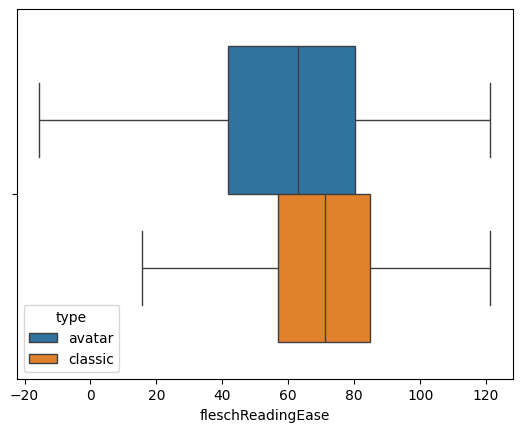

In [ ]:
EDA(followupMessages, 'type', 'fleschReadingEase')
ANALYSISPAIR(followupMessages, 'type', 'fleschReadingEase')
EDAPLOT(followupMessages, 'type', 'fleschReadingEase')

,mean,std
form,,
bfi,10731.613655,18538.356699
cfq,10460.414147,11262.083164


yulesK                                          
              0.00 0.25         0.50          0.75      1.00
form                                                        
bfi  -6.938894e-12  0.0  8888.888889  16032.258065  500000.0
cfq  -6.938894e-12  0.0  9466.097745  16528.925620   93750.0

['bfi' 'cfq']
0.0015  0.0009  

bfi: M=8130.39, SD=6007.3, MED=9591.84, IQR=(0.0-13308.41)
cfq: M=8394.91, SD=5820.71, MED=9600.0, IQR=(1913.27-12804.36)

median
U(80)=786.5, z=-0.13, p=0.9002, r=-0.01 [-0.23, 0.2], ps=0.49 [0.37, 0.62]

median bfi < cfq
U(80)=786.5, p=0.4500884836699025

median bfi > cfq
U(80)=786.5, p=0.5537283994297206

variance
F(1, 80)=0.09, p=0.7706

mean
U(80)=791.0, p=0.9348126839238233

no aggregation
U(2265)=630884.5, p=0.5737700648349615

              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   yulesK        
No. Observations:   2265      Method:               REML          
No. Groups:         80        Scale:                224240190.8249
Min. group size:    25        Log-Likelihood:       -25019.4040   
Max. group size:    30        Converged:            Yes           
Mean group size:    28.3                                          
------------------------------------------------------------------
        

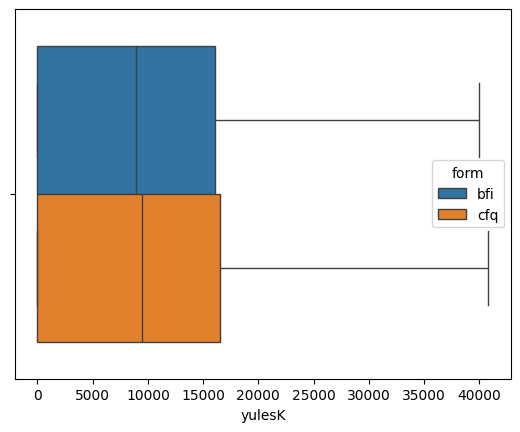

In [65]:
EDA(followupMessages, 'form', 'yulesK')
ANALYSISPAIR(followupMessages, 'form', 'yulesK')
EDAPLOT(followupMessages, 'form', 'yulesK')

,mean,std
form,,
bfi,61.602679,33.056548
cfq,67.094233,30.042704


fleschReadingEase                                      
                  0.00       0.25    0.50       0.75    1.00
form                                                        
bfi        -101.076319  45.601786  65.725  81.855000  121.22
cfq        -301.780000  54.725000  69.785  84.048276  121.22

['bfi' 'cfq']
0.0001  0.002  

bfi: M=62.89, SD=20.17, MED=67.89, IQR=(58.43-75.54)
cfq: M=68.56, SD=14.73, MED=70.22, IQR=(63.49-77.74)

median
U(80)=701.0, z=-0.95, p=0.3432, r=-0.11 [-0.32, 0.11], ps=0.44 [0.31, 0.56]

median bfi < cfq
U(80)=701.0, p=0.17160290583721066

median bfi > cfq
U(80)=701.0, p=0.8308356815549611

variance
F(1, 80)=1.27, p=0.2627

mean
U(80)=679.0, p=0.24624763331118316

no aggregation
U(2265)=571259.5, p=1.1254614970796244e-05

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fleschReadingEase
No. Observations: 2265    Method:             REML             
No. Groups:       80      Scale:              713.2963         
Min. group size:  25      Log-Likelihood:     -10750.9501      
Max. group size:  30      Converged:          Yes              
Mean group size:  28.3                                         
----------------------------------------------------------------
                 Coef.   Std.Err.    z 

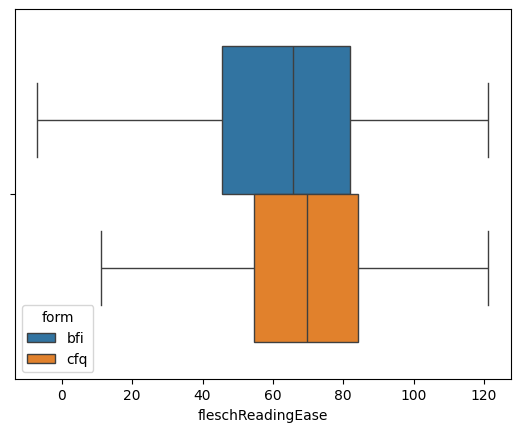

In [ ]:
EDA(followupMessages, 'form', 'fleschReadingEase')
ANALYSISPAIR(followupMessages, 'form', 'fleschReadingEase')
EDAPLOT(followupMessages, 'form', 'fleschReadingEase')

,mean,std
type,,
avatar,13761.625934,22756.979010
classic,7711.752171,12341.881292


yulesK                                                        
                 0.00         0.25          0.50          0.75           1.00
type                                                                         
avatar   0.000000e+00  5051.020408  1.248699e+04  18518.518519  500000.000000
classic -6.938894e-12     0.000000  2.775558e-11  12345.679012  166666.666667

['avatar' 'classic']
0.0814  0.0022  

avatar: M=11211.86, SD=5129.48, MED=12078.91, IQR=(9366.67-14273.99)
classic: M=5048.93, SD=5269.98, MED=4211.13, IQR=(0.0-9717.66)

median
U(40)=321.5, z=3.28, p=0.001, r=0.52 [0.27, 0.73], ps=0.8 [0.66, 0.93]

median avatar < classic
U(40)=321.5, p=0.9995273495460559

median avatar > classic
U(40)=321.5, p=0.0005204742174994339

variance
F(1, 40)=1.15, p=0.2913

mean
U(40)=334.0, p=0.0003047989167029454

no aggregation
U(1192)=237524.5, p=1.5731883448667078e-24

                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    yulesK        
No. Observations:     1192       Method:                REML          
No. Groups:           40         Scale:                 322711486.1180
Min. group size:      27         Log-Likelihood:        -13367.0459   
Max. group size:      30         Converged:             Yes           
Mean group size:      29.8                                            
------------

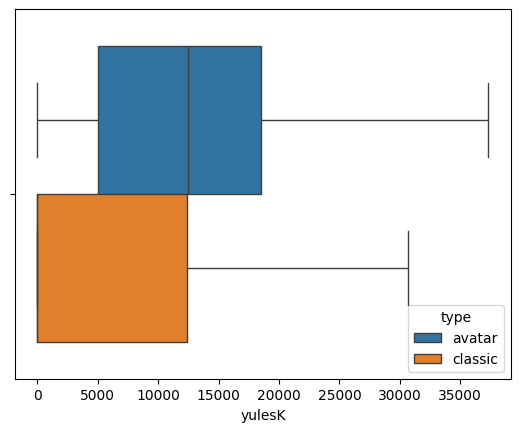

In [67]:
EDA(followupMessages[followupMessages.form=='bfi'], 'type', 'yulesK')
ANALYSISPAIR(followupMessages[followupMessages.form=='bfi'], 'type', 'yulesK')
EDAPLOT(followupMessages[followupMessages.form=='bfi'], 'type', 'yulesK')

,mean,std
type,,
avatar,12017.281351,12108.482107
classic,8923.728555,10138.208225


yulesK                                          
                 0.00 0.25          0.50          0.75     1.00
type                                                           
avatar  -6.938894e-12  0.0  11834.319527  18518.518519  93750.0
classic -6.938894e-12  0.0   6920.415225  14302.368824  80000.0

['avatar' 'classic']
0.0045  0.0037  

avatar: M=9867.57, SD=6301.3, MED=12115.51, IQR=(5267.38-15096.12)
classic: M=6922.25, SD=5027.17, MED=8888.89, IQR=(0.0-10547.85)

median
U(40)=274.5, z=2.01, p=0.0444, r=0.32 [0.01, 0.6], ps=0.69 [0.5, 0.85]

median avatar < classic
U(40)=274.5, p=0.9791889591228243

median avatar > classic
U(40)=274.5, p=0.022209489767930232

variance
F(1, 40)=0.82, p=0.3704

mean
U(40)=291.0, p=0.014363847601136414

no aggregation
U(1073)=168202.0, p=1.2241503995920043e-06

                Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    yulesK        
No. Observations:     1073       Method:                REML          
No. Groups:           40         Scale:                 114489756.2474
Min. group size:      25         Log-Likelihood:        -11486.4028   
Max. group size:      27         Converged:             Yes           
Mean group size:      26.8                                            
---------------

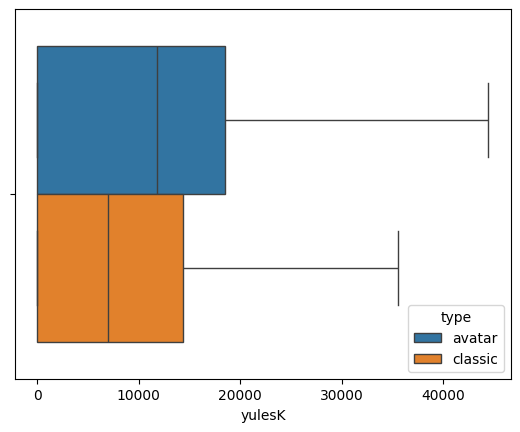

In [68]:
EDA(followupMessages[followupMessages.form=='cfq'], 'type', 'yulesK')
ANALYSISPAIR(followupMessages[followupMessages.form=='cfq'], 'type', 'yulesK')
EDAPLOT(followupMessages[followupMessages.form=='cfq'], 'type', 'yulesK')

,mean,std
type,,
avatar,52.086706,36.619228
classic,71.086774,25.819925


fleschReadingEase                                         
                     0.00       0.25       0.50       0.75    1.00
type                                                              
avatar        -101.076319  35.059623  57.704286  76.826354  121.22
classic        -48.995000  54.701429  70.144706  85.139474  121.22

['avatar' 'classic']
0.0209  0.6919  

avatar: M=53.83, SD=23.79, MED=63.44, IQR=(40.93-72.54)
classic: M=71.96, SD=9.8, MED=72.97, IQR=(66.0-77.14)

median
U(40)=110.0, z=-2.42, p=0.0155, r=-0.38 [-0.63, -0.1], ps=0.28 [0.13, 0.44]

median avatar < classic
U(40)=110.0, p=0.007739301221419287

median avatar > classic
U(40)=110.0, p=0.9928180761994317

variance
F(1, 40)=7.18, p=0.0108

mean
U(40)=101.0, p=0.007711805017936965

no aggregation
U(1192)=126206.5, p=5.165037640718831e-18

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fleschReadingEase
No. Observations: 1192    Method:             REML             
No. Groups:       40      Scale:              706.3067         
Min. group size:  27      Log-Likelihood:     -5648.7131       
Max. group size:  30      Converged:          Yes              
Mean group size:  29.8                                         
---------------------------------------------------------------
             

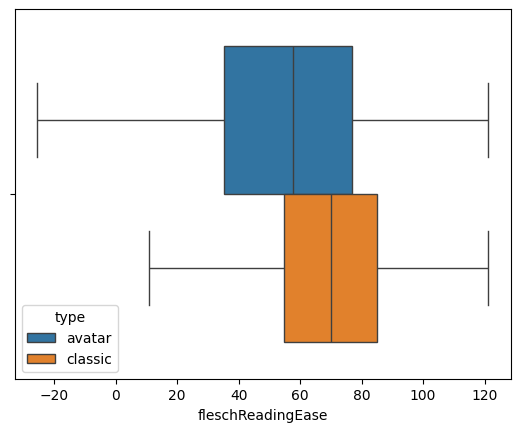

In [69]:
EDA(followupMessages[followupMessages.form=='bfi'], 'type', 'fleschReadingEase')
ANALYSISPAIR(followupMessages[followupMessages.form=='bfi'], 'type', 'fleschReadingEase')
EDAPLOT(followupMessages[followupMessages.form=='bfi'], 'type', 'fleschReadingEase')

,mean,std
type,,
avatar,63.175688,30.725177
classic,70.961982,28.864051


fleschReadingEase                                         
                     0.00       0.25       0.50       0.75    1.00
type                                                              
avatar             -78.21  48.734091  67.465385  83.009231  121.22
classic           -301.78  59.636000  71.767857  84.858750  121.22

['avatar' 'classic']
0.0628  0.0581  

avatar: M=65.32, SD=18.54, MED=71.16, IQR=(53.85-76.58)
classic: M=71.8, SD=8.9, MED=69.42, IQR=(63.57-77.99)

median
U(40)=174.0, z=-0.69, p=0.4903, r=-0.11 [-0.41, 0.21], ps=0.44 [0.26, 0.62]

median avatar < classic
U(40)=174.0, p=0.24512642446526484

median avatar > classic
U(40)=174.0, p=0.7633011929351892

variance
F(1, 40)=3.41, p=0.0727

mean
U(40)=157.0, p=0.25029679750351164

no aggregation
U(1073)=122885.5, p=3.4373560190708e-05

             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fleschReadingEase
No. Observations: 1073    Method:             REML             
No. Groups:       40      Scale:              721.1502         
Min. group size:  25      Log-Likelihood:     -5088.3886       
Max. group size:  27      Converged:          Yes              
Mean group size:  26.8                                         
---------------------------------------------------------------
                 

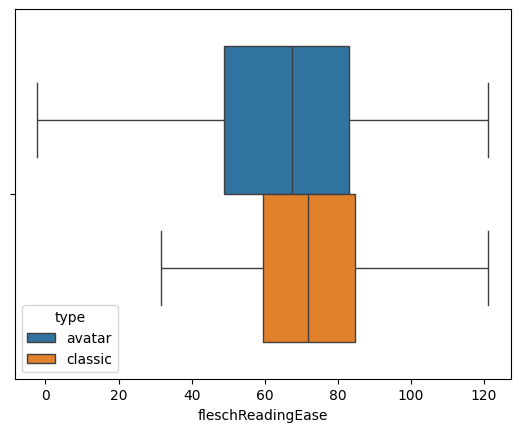

In [70]:
EDA(followupMessages[followupMessages.form=='cfq'], 'type', 'fleschReadingEase')
ANALYSISPAIR(followupMessages[followupMessages.form=='cfq'], 'type', 'fleschReadingEase')
EDAPLOT(followupMessages[followupMessages.form=='cfq'], 'type', 'fleschReadingEase')

# Self-disclosure and authenticity

In [ ]:
feedbackQs = {
    'authenticity': 'How much do you agree with this statement: The conversation with the AI assistant felt natural.',
    'experience': "How would you rate the overall experience of interacting with the AI assistant?",
    'experience-survey': "How would you rate your overall experience with this survey?",
    'choose-voice': 'During this survey, you interacted with a voice-based AI assistant. If you had to choose, would you prefer this format or a text-based assistant (where you communicate by typing) for a similar survey in the future?',
    'choose-text': 'During this survey, you interacted with a text-based AI assistant. If you had to choose, would you prefer this format or a voice-based assistant (where the AI speaks to you, and you also respond by speaking) for a similar survey in the future?'
}
data = followupMessages.groupby(['respondentID', 'type']).agg({
    'self-disclosure': 'mean',
    'informativeness': 'median',
    'wordCount': 'median'
}).reset_index()
answers = pd.read_csv("data/answers.csv", index_col=0)
answers_auth = answers[answers.question==feedbackQs['authenticity']][['respondent', 'answer']]
answers_exp = answers[answers.question==feedbackQs['experience']][['respondent', 'answer']]
answers_exp2 = answers[answers.question==feedbackQs['experience-survey']][['respondent', 'answer']]
# answers_cv = answers[answers.question==feedbackQs['choose-voice']][['respondent', 'answer']]
# answers_ct = answers[answers.question==feedbackQs['choose-text']][['respondent', 'answer']]
data = data.merge(answers_auth, left_on='respondentID', right_on='respondent', how='left').rename(columns={'answer': 'authenticity'}).drop(columns=['respondent'])
data = data.merge(answers_exp, left_on='respondentID', right_on='respondent', how='left').rename(columns={'answer': 'experience'}).drop(columns=['respondent'])
data = data.merge(answers_exp2, left_on='respondentID', right_on='respondent', how='left').rename(columns={'answer': 'experience-survey'}).drop(columns=['respondent'])
# data = data.merge(answers_cv, left_on='respondentID', right_on='respondent', how='left').rename(columns={'answer': 'choose-voice'}).drop(columns=['respondent'])
# data = data.merge(answers_ct, left_on='respondentID', right_on='respondent', how='left').rename(columns={'answer': 'choose-text'}).drop(columns=['respondent'])
mapping = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly agree': 5
}
mapping2 = {'Very poor': 1,
    'Poor': 2,
    'Neutral': 3,   
    'Good': 4,
    'Very good': 5}
data.authenticity = data.authenticity.apply(lambda x: mapping[x] if not pd.isnull(x) else np.nan)
data.experience = data.experience.apply(lambda x: mapping2[x] if not pd.isnull(x) else np.nan)
data['experience-survey'] = data['experience-survey'].apply(lambda x: mapping2[x] if not pd.isnull(x) else np.nan)

In [ ]:
print(spearmanr(data.dropna()['self-disclosure'], data.dropna()['authenticity']))
print(spearmanr(data['self-disclosure'], data['experience']))
print(spearmanr(data['self-disclosure'], data['experience-survey']))

In [ ]:
print(spearmanr(data.dropna()['informativeness'], data.dropna()['authenticity']))
print(spearmanr(data.dropna()['informativeness'], data.dropna()['experience']))
print(spearmanr(data.dropna()['informativeness'], data.dropna()['experience-survey']))

In [ ]:
mannwhitneyu(data[(data.type=='avatar') & (data.authenticity<4)]['self-disclosure'], data[(data.type=='avatar') & (data.authenticity>=4)]['self-disclosure'])

In [ ]:
mannwhitneyu(data[(data.type=='avatar') & (data.authenticity<4)]['informativeness'], data[(data.type=='avatar') & (data.authenticity>=4)]['informativeness'])